#  EDA: Análise Exploratória do Funil de Vendas Olist

**Objetivo:** Investigar o dataset mestre da Olist para identificar gargalos, ineficiências e padrões no ciclo de vida dos pedidos. As conclusões desta análise servirão de base para a construção do dashboard final e para as recomendações de negócio.

**Estrutura da Análise:**
1.  **Configuração Inicial:** Carregamento das bibliotecas e do dataset processado.
2.  **Análise de Cancelamentos:** Investigar os principais motivos e perfis de pedidos cancelados.
3.  **Análise do Funil Operacional e Outliers:** Mapear o tempo gasto em cada etapa e entender os impactos dos outliers.
4.  **Análise de Performance de Entrega:** Avaliar a pontualidade e os fatores que impactam atrasos.
5.  **Análise Geográfica:** Entender o impacto da localização na logística.


In [327]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

path = '/home/portugal/Documentos/Projects/GitHub/AnaliseFunilDeVendas/data/'

In [328]:
sns.set_style('whitegrid')
plt.style.use('ggplot')

def valores_acima_barra():
    for p in ax.patches:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=12, color='black', xytext=(0,5), textcoords='offset points')
    return 
    


In [329]:
try:
    processed_path = os.path.join('..', 'data', 'processed', 'olist_master_dataset.parquet')
    df = pd.read_parquet(processed_path)
    print("Dataset mestre carregado com sucesso!")
    print(f"Shape do DataFrame: {df.shape}")
except FileNotFoundError:
    print(f"ERRO: Arquivo não encontrado em '{processed_path}'. Certifique-se de que o pipeline de ETL foi executado.")


Dataset mestre carregado com sucesso!
Shape do DataFrame: (118434, 37)


In [330]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 118434 entries, 0 to 118433
Data columns (total 37 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       118434 non-null  object        
 1   customer_id                    118434 non-null  object        
 2   order_status                   118434 non-null  object        
 3   order_purchase_timestamp       118434 non-null  datetime64[ns]
 4   order_approved_at              118258 non-null  datetime64[ns]
 5   order_delivered_carrier_date   116360 non-null  datetime64[ns]
 6   order_delivered_customer_date  115037 non-null  datetime64[ns]
 7   order_estimated_delivery_date  118434 non-null  datetime64[ns]
 8   order_item_id                  117604 non-null  float64       
 9   product_id                     117604 non-null  object        
 10  seller_id                      117604 non-null  object        
 11  

### Análise de Cancelamentos

* Qual é o perfil dos pedidos cancelados? 
* Qual o total de cancelamento?
* Qual a porcentagem de cancelamento ?
* Existem padrões relacionados à localização do cliente ou ao método de pagamento?

In [331]:
df_canceled = df[df['order_status'] == 'canceled'].copy()

print(f'Total de pedidos cancelados: {len(df_canceled)}')
print(f'Porcentagem de pedidos cancelados: {len(df_canceled) / len(df) * 100:.2f}% ')

# plt.figure(figsize=(10,6))

# plt.title('Cancelamento %', loc='left', pad=10)


Total de pedidos cancelados: 745
Porcentagem de pedidos cancelados: 0.63% 


/tmp/ipykernel_8053/1452605812.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_10_canceled_states.index, y=top_10_canceled_states.values, palette='viridis')


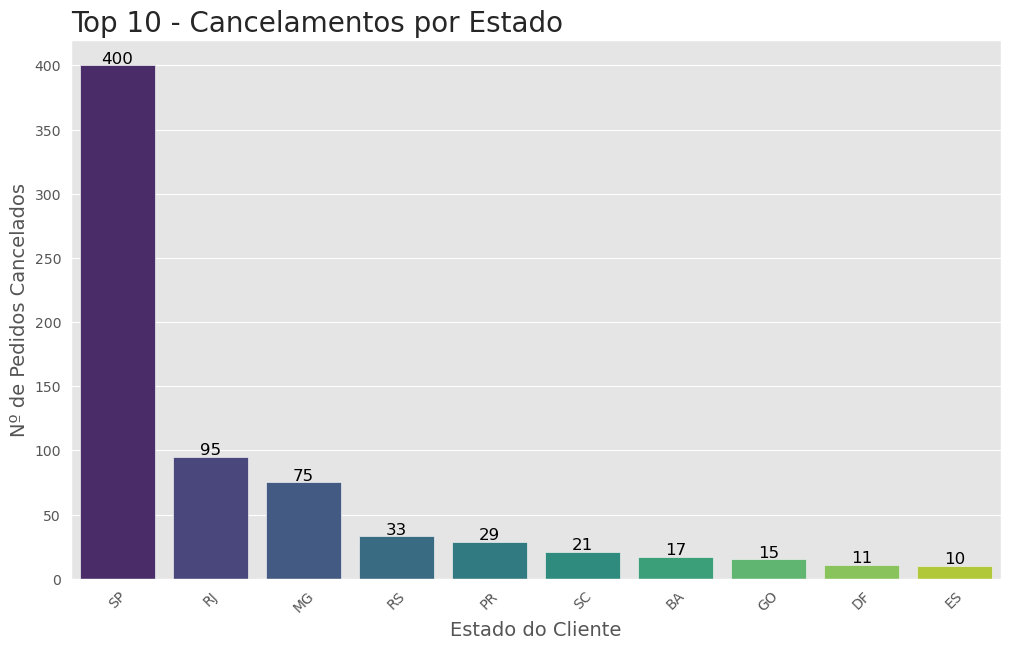

In [332]:
top_10_canceled_states = df_canceled['customer_state'].value_counts().nlargest(10)

plt.figure(figsize=(12, 7))

ax = sns.barplot(x=top_10_canceled_states.index, y=top_10_canceled_states.values, palette='viridis')
# ax = sns.barplot(hue=top_10_canceled_states.index, y=top_10_canceled_states.values, legend=True)

plt.title('Top 10 - Cancelamentos por Estado', loc='left', fontsize=20)

plt.xlabel('Estado do Cliente', fontsize=14)
plt.xticks(rotation=45)

plt.ylabel('Nº de Pedidos Cancelados', fontsize=14)

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', fontsize=12, color='black', xytext=(0,5), textcoords='offset points')

**Insight:** O estado de São Paulo (SP) lidera disparadamente o número de cancelamentos, seguido pelo Rio de Janeiro (RJ) e Minas Gerais (MG). Embora isso seja esperado, já que são os maiores mercados, a proporção pode indicar problemas específicos nessas regiões.


/tmp/ipykernel_8053/4196170634.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=canceled_by_payment.index, y=canceled_by_payment.values, palette='mako', legend=True)


Text(1.0, 1.0, 'Cancelamento por Metodo de Pagamento')

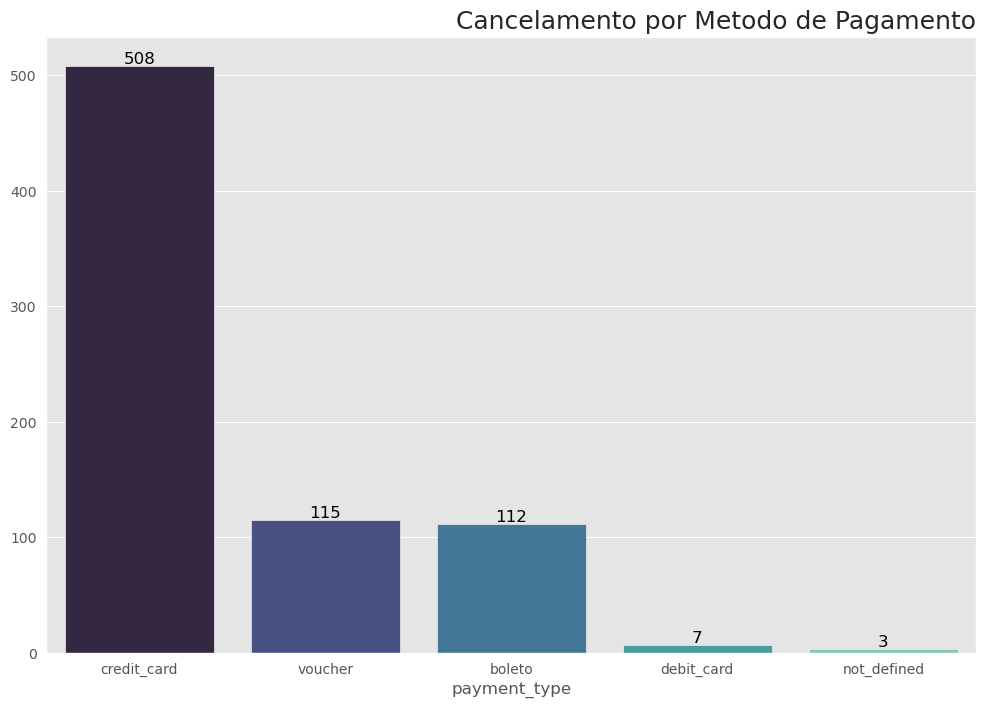

In [333]:
canceled_by_payment = df_canceled['payment_type'].value_counts()

plt.figure(figsize=(12,8))
ax = sns.barplot(x=canceled_by_payment.index, y=canceled_by_payment.values, palette='mako', legend=True)
valores_acima_barra()

plt.title('Cancelamento por Metodo de Pagamento', loc='right', fontsize=18)



**Insight:** A maioria esmagadora dos cancelamentos ocorre em pedidos feitos com cartão de crédito, seguido por boleto. O fato de "cartão de crédito" ser o líder pode ser contraintuitivo e merece uma investigação mais profunda. Possíveis causas:

1.  **Falha na aprovação pela operadora:** O pedido é criado, mas o pagamento é recusado.
2.  **Fraude:** Detecção de fraude que leva ao cancelamento.
3.  **Arrependimento rápido:** O cliente compra por impulso e cancela logo em seguida.

# Cancelamentos por Estado

Com essa query os dados de cancelamento de **SP, RJ, MG** chamam atenção

<Axes: title={'left': 'Cancelamentos'}, xlabel='order_status', ylabel='count'>

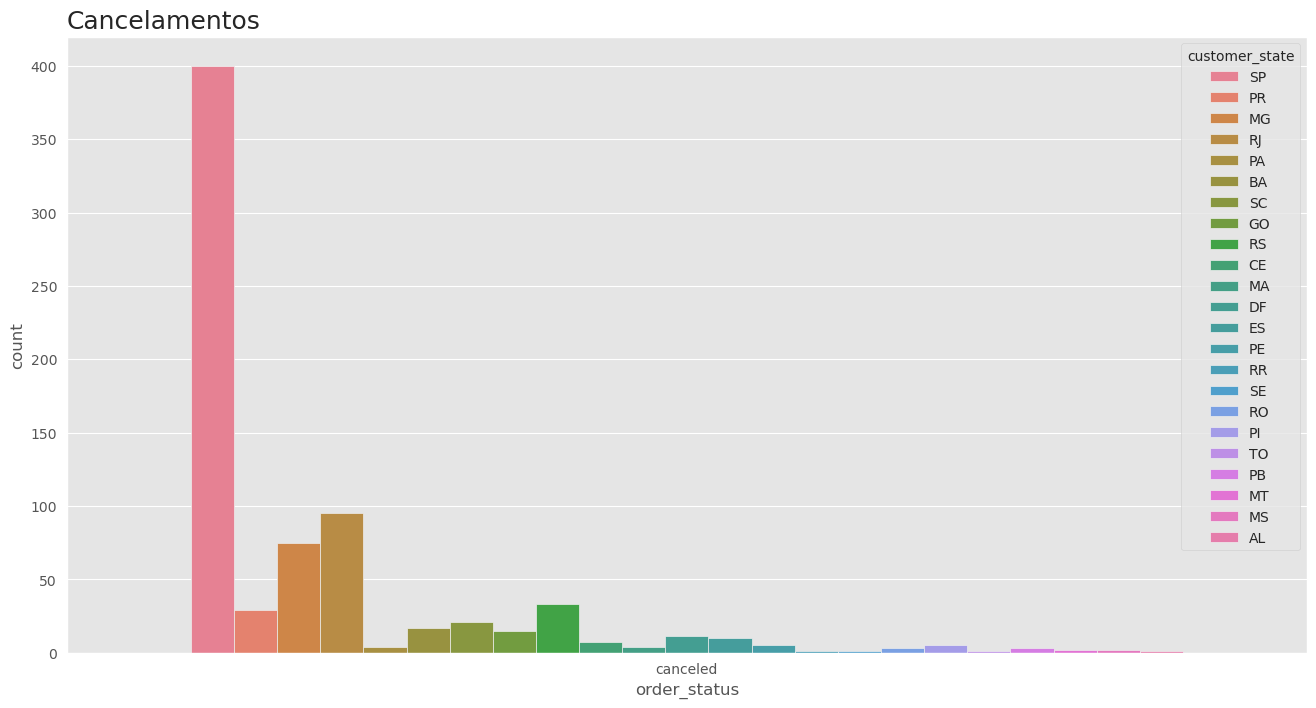

In [334]:
plt.style.use('ggplot')

plt.figure(figsize=(16,8))

plt.title('Cancelamentos', loc='left',fontsize=18)
"""  """
sns.countplot(data=df_canceled, x=df_canceled['order_status'], hue='customer_state')

### 3. Análise do Funil Operacional

**Pergunta de Negócio:** Quanto tempo, em média, um pedido leva em cada etapa do nosso processo interno (aprovação, despacho)? Onde estão os maiores "delays"?

**Metodologia:** Vamos calcular a diferença (delta) entre os timestamps de cada etapa para criar novas colunas de duração. Depois, analisaremos a distribuição desses tempos.

In [335]:
df['tempo_aprovacao'] = (df['order_approved_at'] - df['order_purchase_timestamp']).dt.total_seconds() / (60*60*24)
df['tempo_despacho_vendedor'] = (df['order_delivered_carrier_date'] -df['order_approved_at']).dt.total_seconds()  / (60*60*24)
df['tempo_entrega_transportadora'] = (df['order_delivered_customer_date'] - df['order_delivered_carrier_date']).dt.total_seconds() / (60*60*24)
df['tempo_total_entrega'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.total_seconds() / (60*60*24)

# Calculando a diferença em relação à estimativa
df['diferenca_estimativa'] = (df['order_estimated_delivery_date'] - df['order_delivered_customer_date']).dt.total_seconds() / (60*60*24)


In [336]:
# Descrevendo as estatísticas das novas colunas de tempo
metricas_tempo = ['tempo_aprovacao', 'tempo_despacho_vendedor', 'tempo_entrega_transportadora', 'tempo_total_entrega', 'diferenca_estimativa']
print("Estatísticas Descritivas dos Tempos do Funil (em dias):")
df[metricas_tempo].describe().transpose()

Estatísticas Descritivas dos Tempos do Funil (em dias):


,count,mean,std,min,25%,50%,75%,max
tempo_aprovacao,118258.0,0.440832,1.083144,0.000000,0.008981,0.014456,0.625622,187.882523
tempo_despacho_vendedor,116345.0,2.854442,3.594875,-171.219005,0.886563,1.846042,3.644884,125.762569
tempo_entrega_transportadora,115036.0,9.200559,8.638945,-16.096169,4.063649,7.062234,11.927373,205.190972
tempo_total_entrega,115037.0,12.484852,9.455368,0.533414,6.748646,10.196956,15.545093,209.628611
diferenca_estimativa,115037.0,11.345365,10.167300,-188.975081,6.500035,12.056412,16.314664,146.016123


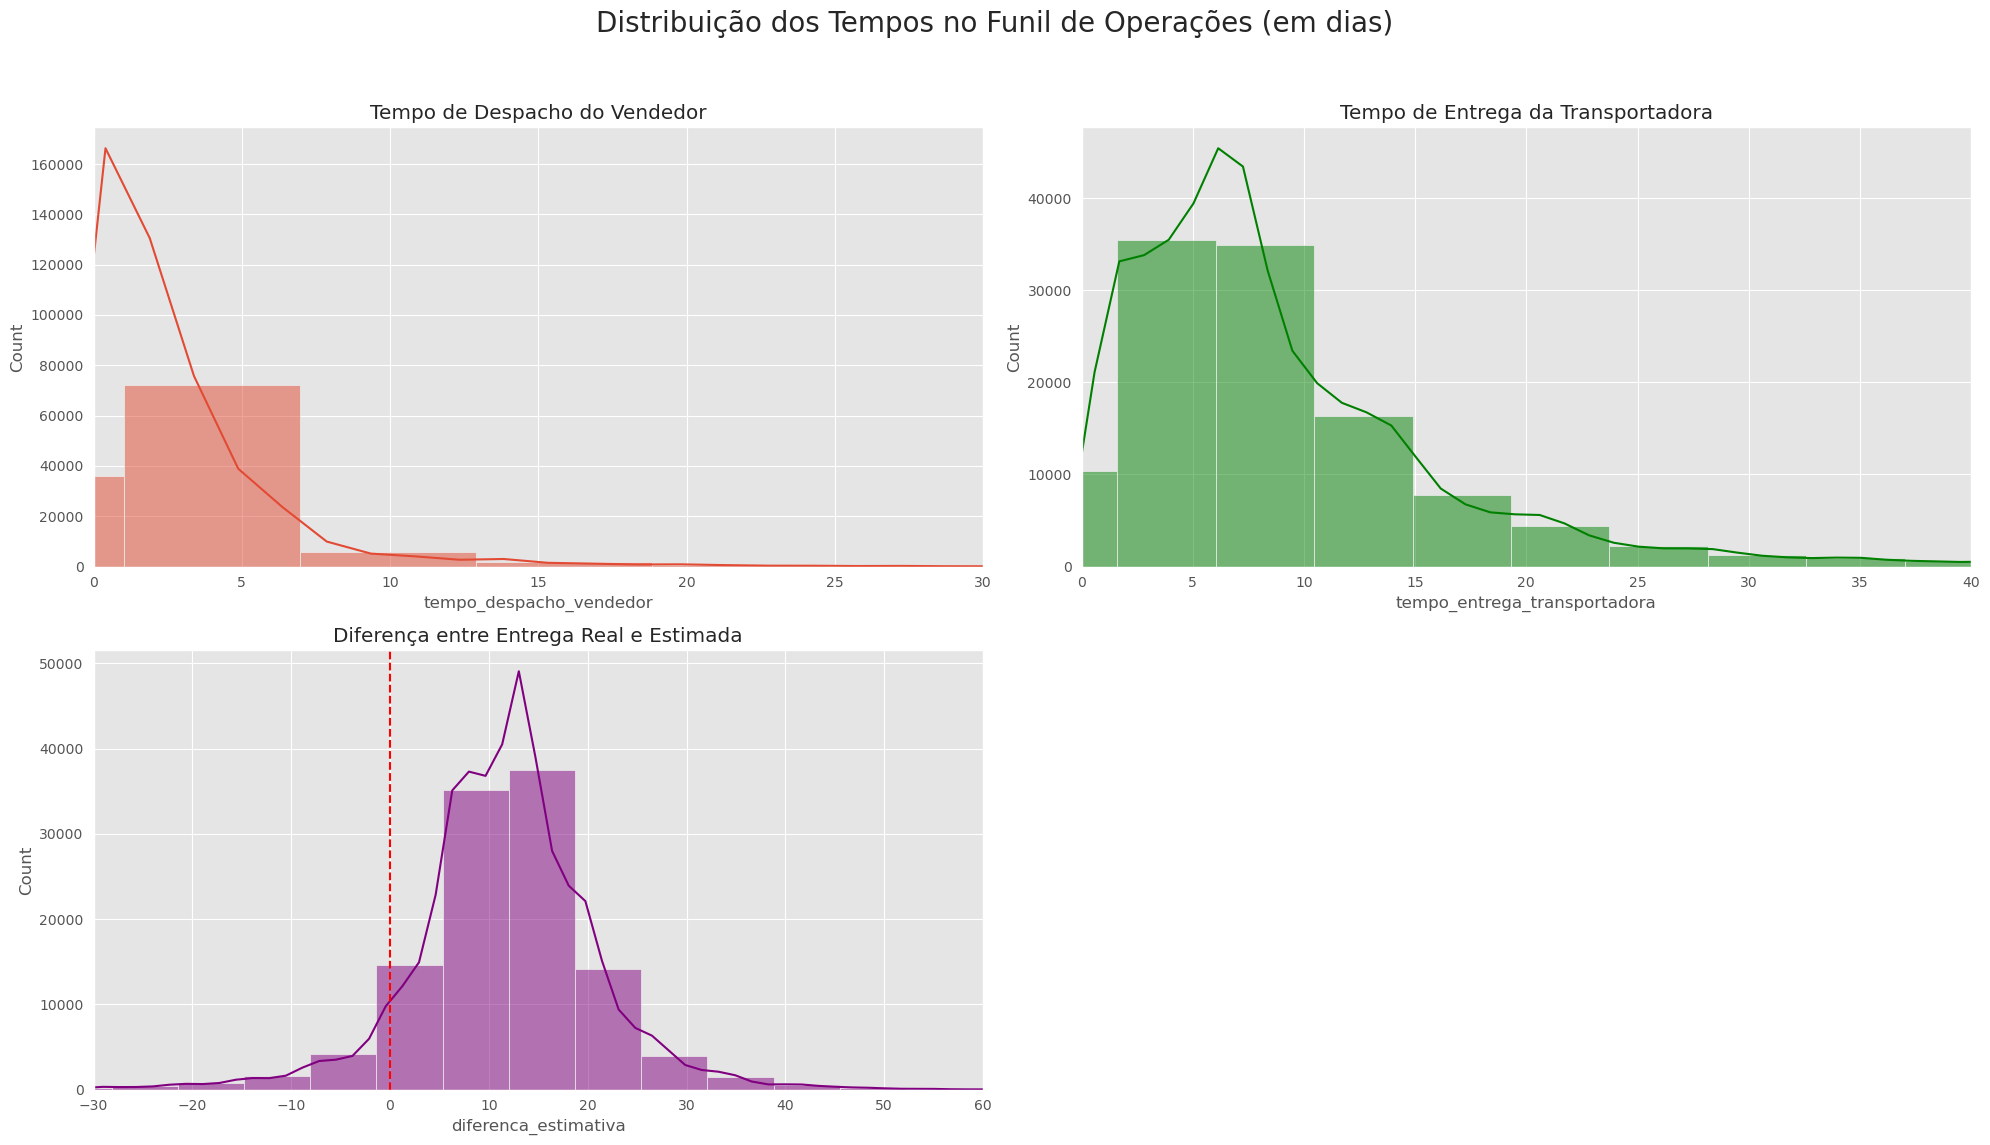

In [337]:

# Visualizando a distribuição dos tempos
plt.figure(figsize=(20, 12))
plt.suptitle('Distribuição dos Tempos no Funil de Operações (em dias)', fontsize=20)

# Gráfico 1: Tempo de Despacho pelo Vendedor
plt.subplot(2, 2, 1)
sns.histplot(df['tempo_despacho_vendedor'].dropna(), kde=True, bins=50)
plt.title('Tempo de Despacho do Vendedor')
plt.xlim(0, 30) # Limitando o eixo x para melhor visualização

# Gráfico 2: Tempo de Entrega pela Transportadora
plt.subplot(2, 2, 2)
sns.histplot(df['tempo_entrega_transportadora'].dropna(), kde=True, bins=50, color='green')
plt.title('Tempo de Entrega da Transportadora')
plt.xlim(0, 40)

# Gráfico 3: Diferença para a Estimativa
plt.subplot(2, 2, 3)
sns.histplot(df['diferenca_estimativa'].dropna(), kde=True, bins=50, color='purple')
plt.title('Diferença entre Entrega Real e Estimada')
plt.axvline(0, color='red', linestyle='--') # Linha para marcar o ponto de atraso
plt.xlim(-30, 60)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


/tmp/ipykernel_8053/1112105294.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='tempo_despacho_vendedor', width=0.35, palette='husl')
/tmp/ipykernel_8053/1112105294.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, y='tempo_entrega_transportadora', width=0.35, palette='husl')


<Axes: title={'center': 'Tempo Entrega Transportadora'}, ylabel='tempo_entrega_transportadora'>

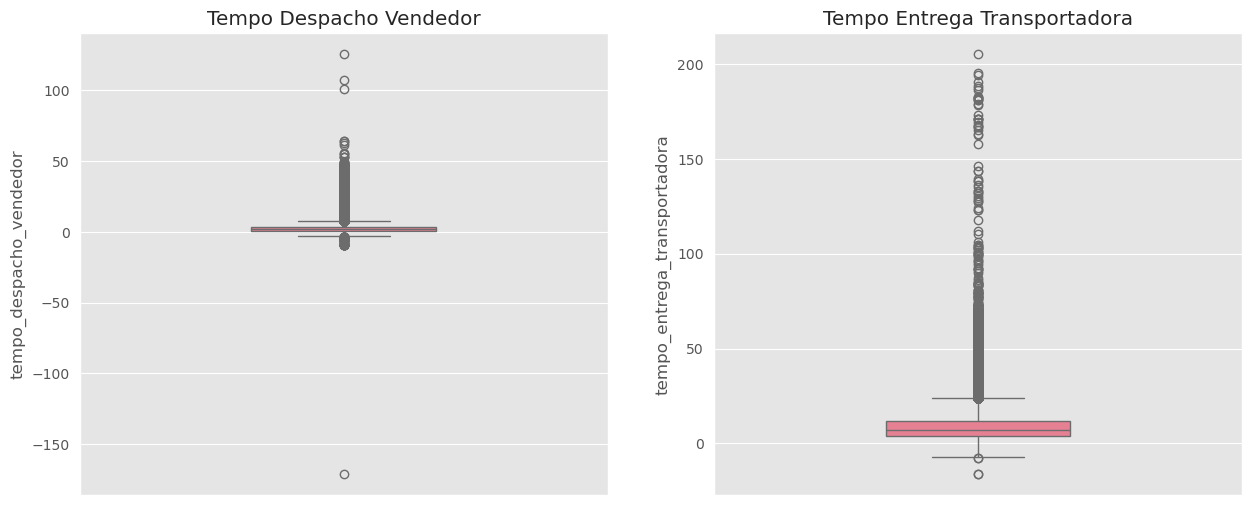

In [338]:
# Figure
plt.figure(figsize=(15,6))


# Grid 1
plt.subplot(1, 2, 1)
# Plot
plt.title('Tempo Despacho Vendedor')
sns.boxplot(data=df, y='tempo_despacho_vendedor', width=0.35, palette='husl')

# Grid 2
plt.subplot(1, 2, 2)
# Plot
plt.title('Tempo Entrega Transportadora')
sns.boxplot(data=df, y='tempo_entrega_transportadora', width=0.35, palette='husl')


In [339]:
Q1 = np.percentile(df['tempo_despacho_vendedor'], 25, interpolation='midpoint')
print(f'Primeiro Quartil: {Q1}')


Q3 = np.percentile(df['tempo_despacho_vendedor'], 75, interpolation='midpoint')
print(f'Primeiro Quartil: {Q3}')

IQR = Q3 - Q1

print(f'{IQR}')

Primeiro Quartil: nan
Primeiro Quartil: nan
nan


In [340]:
# Primeiro, removemos os valores nulos para que o cálculo funcione
tempo_despacho_sem_na = df['tempo_despacho_vendedor'].dropna()

# Calculando Q1, Q3 e IQR
Q1 = tempo_despacho_sem_na.quantile(0.25)
Q3 = tempo_despacho_sem_na.quantile(0.75)
IQR = Q3 - Q1

# Definindo os limites para detecção de outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"Análise de Outliers para 'tempo_despacho_vendedor':")
print(f"Primeiro Quartil (Q1): {Q1:.2f} dias")
print(f"Terceiro Quartil (Q3): {Q3:.2f} dias")
print(f"Intervalo Interquartil (IQR): {IQR:.2f} dias")
print(f"Limite Inferior para Outliers: {limite_inferior:.2f} dias")
print(f"Limite Superior para Outliers: {limite_superior:.2f} dias")

Análise de Outliers para 'tempo_despacho_vendedor':
Primeiro Quartil (Q1): 0.89 dias
Terceiro Quartil (Q3): 3.64 dias
Intervalo Interquartil (IQR): 2.76 dias
Limite Inferior para Outliers: -3.25 dias
Limite Superior para Outliers: 7.78 dias


In [341]:
# Filtrando o DataFrame para remover os outliers
df_sem_outliers = df[(df['tempo_despacho_vendedor'] >= limite_inferior) & 
                    (df['tempo_despacho_vendedor'] <= limite_superior)]

print(f"Tamanho original do DataFrame: {len(df)}")
print(f"Tamanho do DataFrame sem outliers de despacho: {len(df_sem_outliers)}")
print(f"Número de outliers removidos: {len(df) - len(df_sem_outliers)}")


Tamanho original do DataFrame: 118434
Tamanho do DataFrame sem outliers de despacho: 109558
Número de outliers removidos: 8876


 #### Visualizando o Impacto da Remoção de Outliers
 
 **Análise:** Agora vamos plotar o mesmo histograma de antes, mas usando o DataFrame filtrado. Isso nos dará uma visão muito mais clara da performance "típica" dos vendedores.


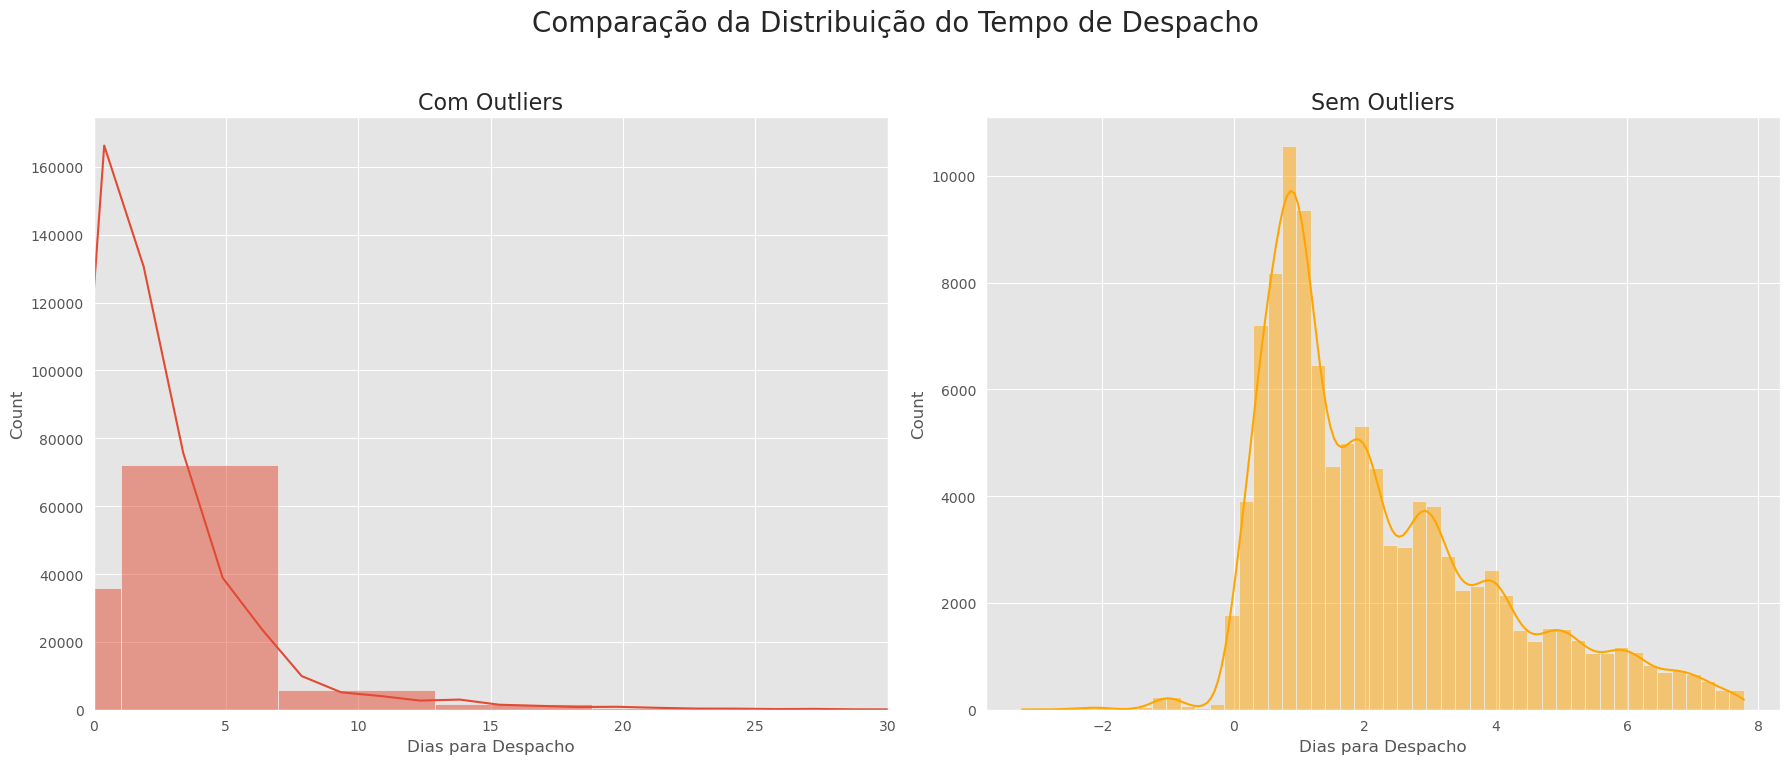

In [342]:
# Comparando as distribuições com e sem outliers
plt.figure(figsize=(18, 8))
plt.suptitle('Comparação da Distribuição do Tempo de Despacho', fontsize=20)

# Gráfico 1: Com Outliers
plt.subplot(1, 2, 1)
sns.histplot(df['tempo_despacho_vendedor'].dropna(), kde=True, bins=50)
plt.title('Com Outliers', fontsize=16)
plt.xlabel('Dias para Despacho')
plt.xlim(0, 30) # Mantendo o mesmo limite para comparação

# Gráfico 2: Sem Outliers
plt.subplot(1, 2, 2)
sns.histplot(df_sem_outliers['tempo_despacho_vendedor'].dropna(), kde=True, bins=50, color='orange')
plt.title('Sem Outliers', fontsize=16)
plt.xlabel('Dias para Despacho')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [343]:
def get_outlier_bounds(series):
    """Calcula os limites inferior e superior para detecção de outliers usando o método IQR."""
    series_sem_na = series.dropna()
    Q1 = series_sem_na.quantile(0.25)
    Q3 = series_sem_na.quantile(0.75)
    IQR = Q3 - Q1
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    return limite_inferior, limite_superior

# Dicionário para armazenar os limites de cada métrica
limites_outliers = {}
for col in metricas_tempo:
    limites_outliers[col] = get_outlier_bounds(df[col])
    print(f"Limites para '{col}': Inferior={limites_outliers[col][0]:.2f}, Superior={limites_outliers[col][1]:.2f}")

# %%
# Criando os DataFrames filtrados
df_sem_outliers_despacho = df[(df['tempo_despacho_vendedor'] >= limites_outliers['tempo_despacho_vendedor'][0]) & 
                            (df['tempo_despacho_vendedor'] <= limites_outliers['tempo_despacho_vendedor'][1])]

df_sem_outliers_entrega = df[(df['tempo_entrega_transportadora'] >= limites_outliers['tempo_entrega_transportadora'][0]) & 
                            (df['tempo_entrega_transportadora'] <= limites_outliers['tempo_entrega_transportadora'][1])]

df_sem_outliers_estimativa = df[(df['diferenca_estimativa'] >= limites_outliers['diferenca_estimativa'][0]) & 
                                (df['diferenca_estimativa'] <= limites_outliers['diferenca_estimativa'][1])]



Limites para 'tempo_aprovacao': Inferior=-0.92, Superior=1.55
Limites para 'tempo_despacho_vendedor': Inferior=-3.25, Superior=7.78
Limites para 'tempo_entrega_transportadora': Inferior=-7.73, Superior=23.72
Limites para 'tempo_total_entrega': Inferior=-6.45, Superior=28.74
Limites para 'diferenca_estimativa': Inferior=-8.22, Superior=31.04


#### Visualizando o Impacto da Remoção de Outliers

**Análise:** Os gráficos abaixo mostram o "antes e depois" para as três principais métricas de tempo. A coluna da esquerda mostra a distribuição original, e a da direita mostra a distribuição após a remoção dos outliers, permitindo uma visão mais clara do comportamento padrão.


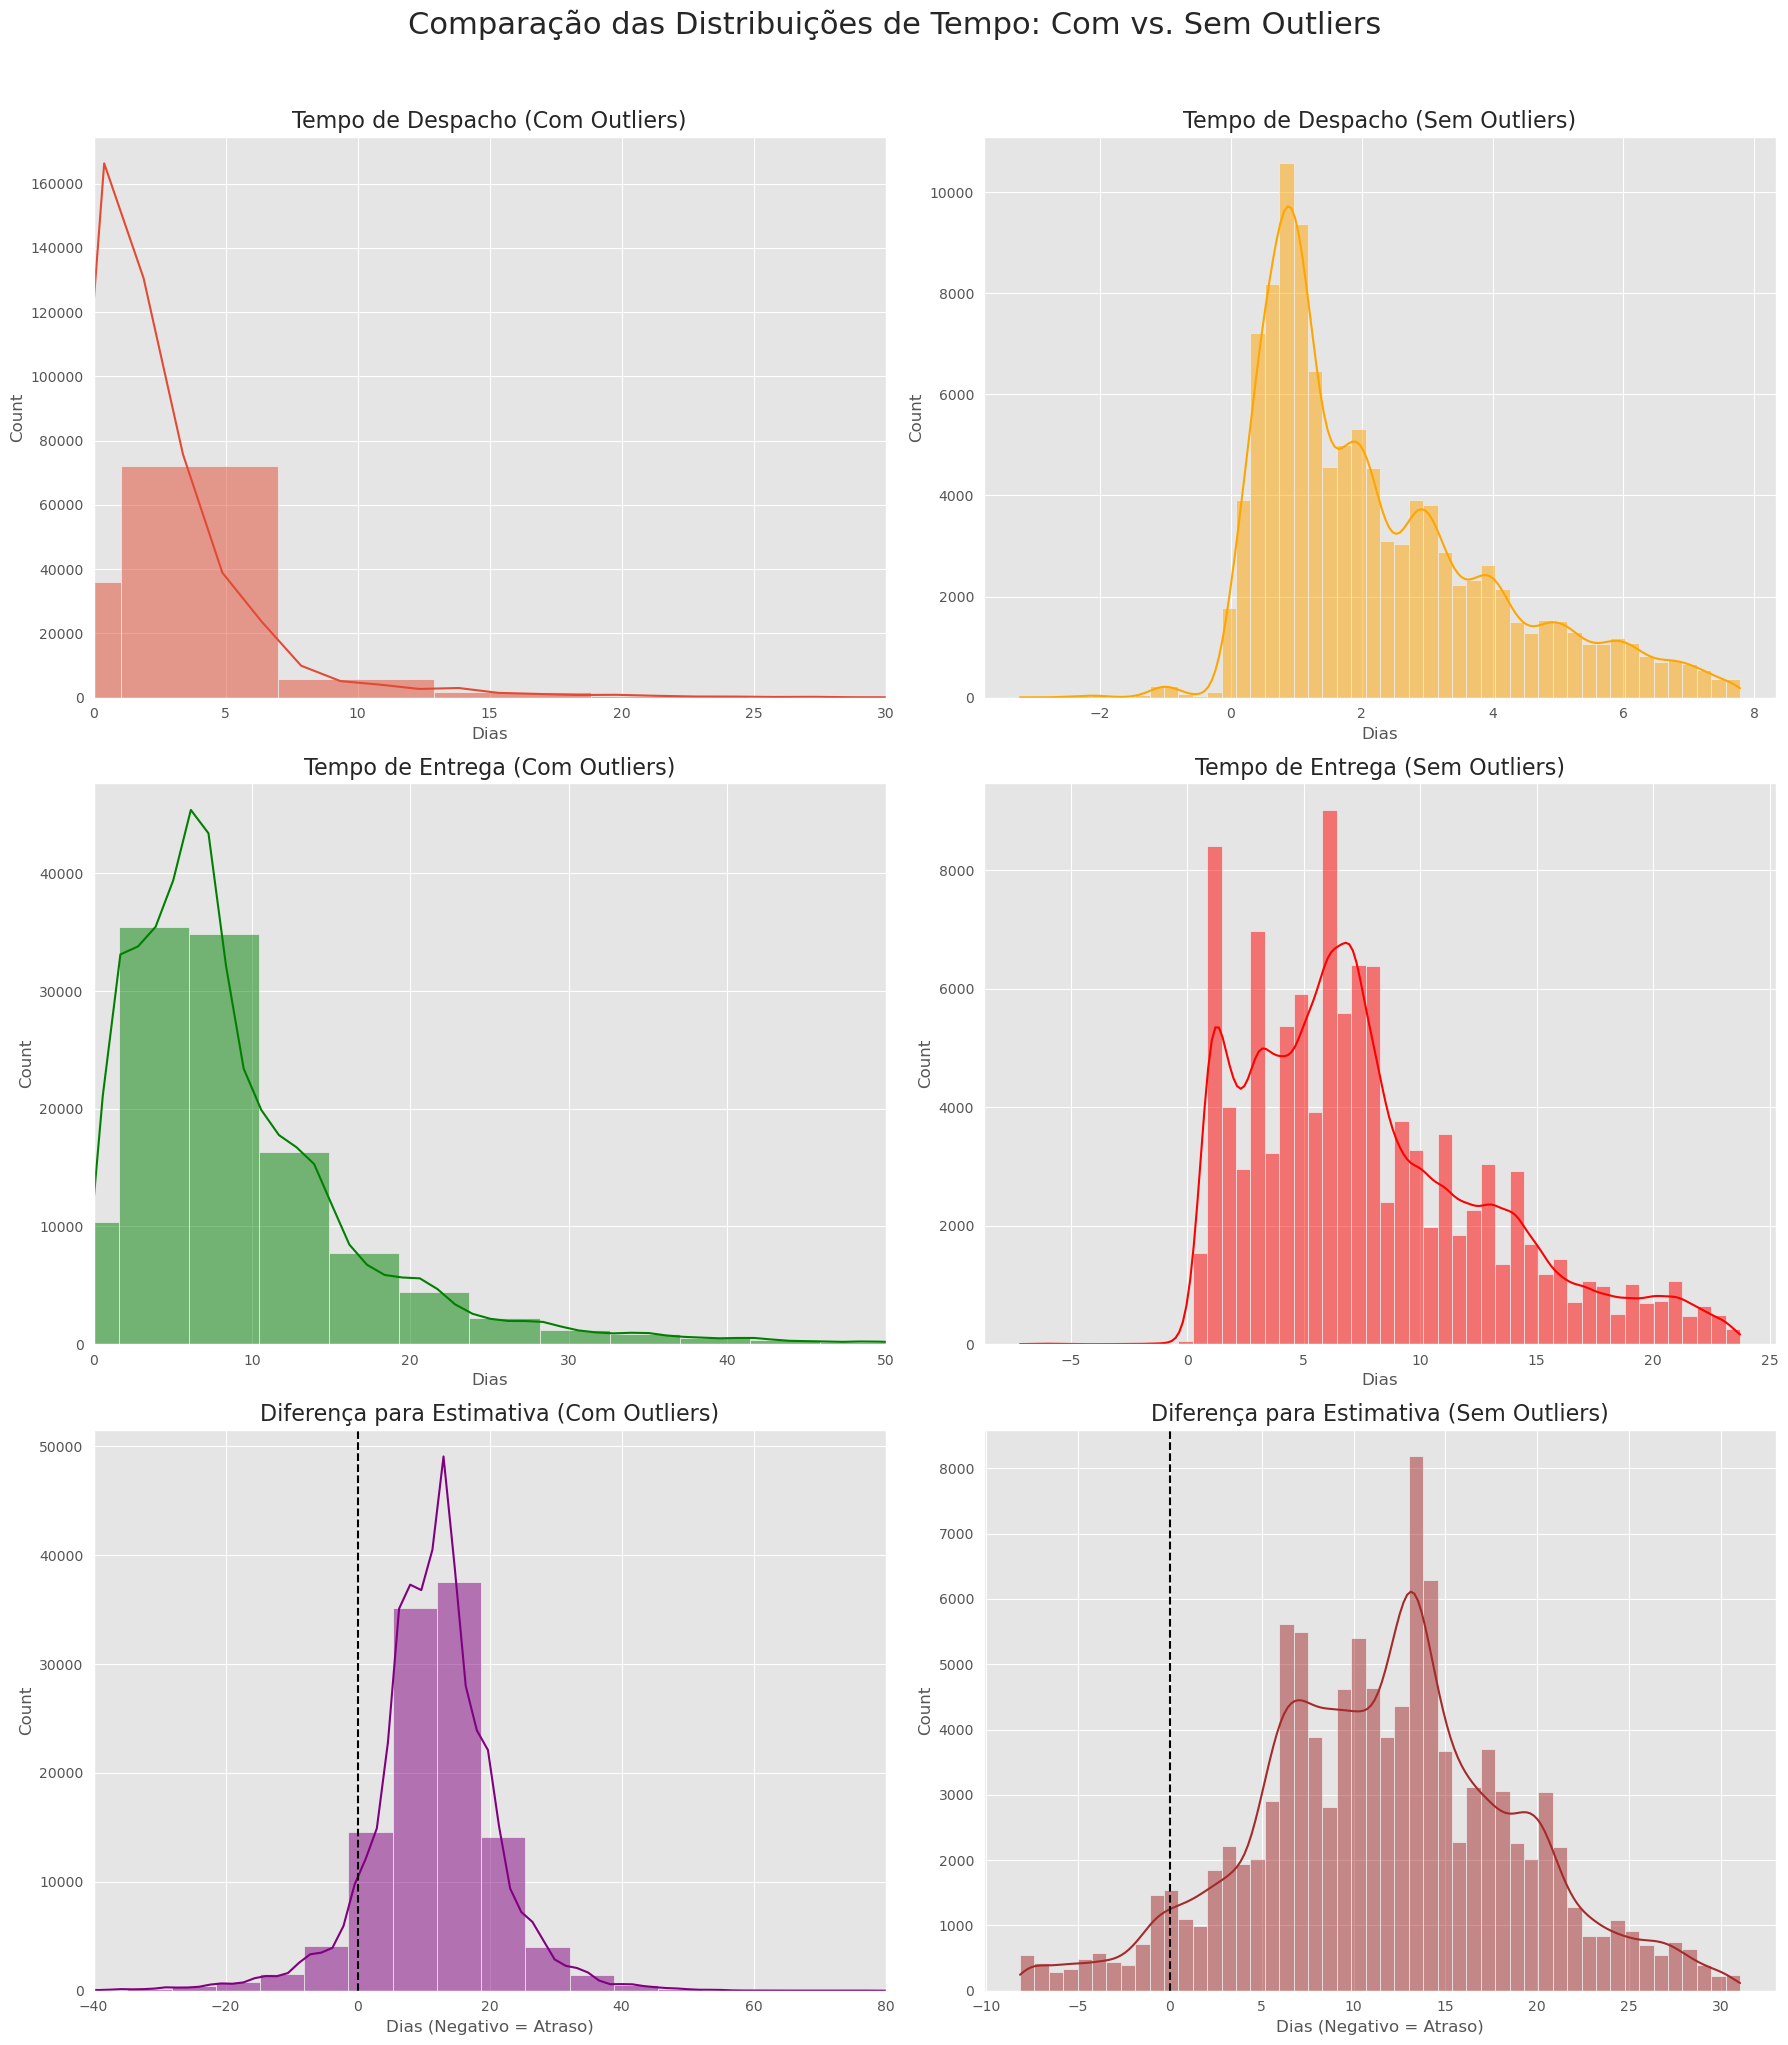

In [344]:
# Criando a visualização comparativa 3x2
fig, axes = plt.subplots(3, 2, figsize=(18, 20))
fig.suptitle('Comparação das Distribuições de Tempo: Com vs. Sem Outliers', fontsize=22, y=1.02)

# --- Linha 1: Tempo de Despacho do Vendedor ---
# Com Outliers
sns.histplot(df['tempo_despacho_vendedor'].dropna(), kde=True, bins=50, ax=axes[0, 0])
axes[0, 0].set_title('Tempo de Despacho (Com Outliers)', fontsize=16)
axes[0, 0].set_xlabel('Dias')
axes[0, 0].set_xlim(0, 30) # Fixando o limite para comparação

# Sem Outliers
sns.histplot(df_sem_outliers_despacho['tempo_despacho_vendedor'].dropna(), kde=True, bins=50, color='orange', ax=axes[0, 1])
axes[0, 1].set_title('Tempo de Despacho (Sem Outliers)', fontsize=16)
axes[0, 1].set_xlabel('Dias')


# --- Linha 2: Tempo de Entrega da Transportadora ---
# Com Outliers
sns.histplot(df['tempo_entrega_transportadora'].dropna(), kde=True, bins=50, color='green', ax=axes[1, 0])
axes[1, 0].set_title('Tempo de Entrega (Com Outliers)', fontsize=16)
axes[1, 0].set_xlabel('Dias')
axes[1, 0].set_xlim(0, 50) # Fixando o limite para comparação

# Sem Outliers
sns.histplot(df_sem_outliers_entrega['tempo_entrega_transportadora'].dropna(), kde=True, bins=50, color='red', ax=axes[1, 1])
axes[1, 1].set_title('Tempo de Entrega (Sem Outliers)', fontsize=16)
axes[1, 1].set_xlabel('Dias')


# --- Linha 3: Diferença para a Estimativa ---
# Com Outliers
sns.histplot(df['diferenca_estimativa'].dropna(), kde=True, bins=50, color='purple', ax=axes[2, 0])
axes[2, 0].set_title('Diferença para Estimativa (Com Outliers)', fontsize=16)
axes[2, 0].set_xlabel('Dias (Negativo = Atraso)')
axes[2, 0].axvline(0, color='black', linestyle='--')
axes[2, 0].set_xlim(-40, 80) # Fixando o limite para comparação

# Sem Outliers
sns.histplot(df_sem_outliers_estimativa['diferenca_estimativa'].dropna(), kde=True, bins=50, color='brown', ax=axes[2, 1])
axes[2, 1].set_title('Diferença para Estimativa (Sem Outliers)', fontsize=16)
axes[2, 1].set_xlabel('Dias (Negativo = Atraso)')
axes[2, 1].axvline(0, color='black', linestyle='--')


plt.tight_layout()
plt.show()

**Storytelling e Insight Final:**

A comparação lado a lado é extremamente reveladora e nos permite entender a operação padrão da Olist de forma muito mais precisa.

1.  **Tempo de Despacho:** A remoção dos outliers mostra que a vasta maioria dos vendedores despacha os produtos em **menos de 7.7 dias**. Os casos que demoram mais que isso são exceções claras e devem ser monitorados.
2.  **Tempo de Entrega:** Vemos um padrão similar na logística. O grosso das entregas acontece em **até 23 dias**. A "cauda longa" de entregas muito demoradas, embora impactante para o cliente, não representa a performance padrão da transportadora.
3.  **Diferença para Estimativa:** Esta é talvez a visão mais interessante. Com outliers, a imagem é distorcida por entregas extremamente adiantadas ou atrasadas. Sem eles, vemos que a performance "normal" da Olist é entregar os produtos com uma antecedência de **até 27 dias** em relação ao prazo prometido. Atrasos (valores negativos) são menos comuns do que os dados brutos sugerem.

**Conclusão para o Dashboard:** Esta análise valida a necessidade de dashboards que permitam uma dupla visão:
* **Visão Gerencial (Sem Outliers):** Para entender a performance do dia a dia e definir metas realistas (SLAs) para vendedores e transportadoras.
* **Visão de Risco (Apenas Outliers):** Um relatório de exceções para identificar e atuar nos casos mais críticos que geram a maior insatisfação do cliente.